# Análisis Exploratorio de Datos (EDA) - TSI
## Traffic Signal Intelligence: Análisis Completo del Tráfico

### Objetivo
Comprender profundamente el comportamiento del tráfico en Guadalajara para:
- Identificar patrones de congestión
- Analizar relaciones entre variables de tráfico
- Comparar datos originales vs filtrados (3 algoritmos seleccionados)
- Informar la construcción de la métrica TSI

### Algoritmos de Filtrado Evaluados
- 🥇 **Isolation Forest** - Detección de anomalías por aislamiento
- 🥈 **Local Outlier Factor** - Detección basada en densidad local
- 🥉 **DBSCAN** - Agrupamiento para detectar outliers

### Entrada
- `data/02_clean/traffic_data.csv` - Datos originales
- `data/02_clean/filtered_isolation_forest.csv` - Isolation Forest
- `data/02_clean/filtered_local_outlier_factor.csv` - Local Outlier Factor
- `data/02_clean/filtered_dbscan.csv` - DBSCAN

### Salida
- Insights sobre patrones de tráfico
- Visualizaciones comparativas
- Recomendaciones para feature engineering

## 1. Configuración y Carga de Datos

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

print('✅ Librerías importadas y configuradas')

✅ Librerías importadas y configuradas


In [2]:
# Rutas de datos
DATA_CLEAN_PATH = '../../data/02_clean/traffic_data.csv'
DATA_IF_PATH = '../../data/02_clean/filtered_isolation_forest.csv'
DATA_LOF_PATH = '../../data/02_clean/filtered_local_outlier_factor.csv'
DATA_DBSCAN_PATH = '../../data/02_clean/filtered_dbscan.csv'

# Cargar datasets
df_original = pd.read_csv(DATA_CLEAN_PATH)
df_if = pd.read_csv(DATA_IF_PATH)
df_lof = pd.read_csv(DATA_LOF_PATH)
df_dbscan = pd.read_csv(DATA_DBSCAN_PATH)

print('✅ Datasets cargados:')
print(f'   Original: {len(df_original)} registros')
print(f'   Isolation Forest: {len(df_if)} registros ({100*len(df_if)/len(df_original):.1f}%)')
print(f'   Local Outlier Factor: {len(df_lof)} registros ({100*len(df_lof)/len(df_original):.1f}%)')
print(f'   DBSCAN: {len(df_dbscan)} registros ({100*len(df_dbscan)/len(df_original):.1f}%)')

✅ Datasets cargados:
   Original: 18 registros
   Isolation Forest: 279 registros (1550.0%)
   Local Outlier Factor: 279 registros (1550.0%)
   DBSCAN: 271 registros (1505.6%)


## 2. Análisis Estructura de Datos

In [3]:
print('ESTRUCTURA DEL DATASET ORIGINAL\n')
print(df_original.head(10))
print(f'\nDimensiones: {df_original.shape}')
print(f'\nTipos de datos:')
print(df_original.dtypes)
print(f'\nValores nulos:')
print(df_original.isnull().sum())
print(f'\nColumnas: {list(df_original.columns)}')

ESTRUCTURA DEL DATASET ORIGINAL

                    timestamp       avenida  velocidad  densidad  detenciones  \
0  2026-03-17 22:31:30.850956  Lopez Mateos       25.0         3          2.0   
1  2026-03-17 22:31:30.859960  Lopez Mateos       20.0         3          2.0   
2  2026-03-17 22:31:30.882579  Lopez Mateos       15.0         3          2.0   
3  2026-03-17 22:42:42.487827  Lopez Mateos       25.0         3          2.0   
4  2026-03-17 22:42:42.493310  Lopez Mateos       20.0         3          2.0   
5  2026-03-17 22:42:42.507905  Lopez Mateos       15.0         3          2.0   
6  2026-03-17 22:43:08.200488  Lopez Mateos       25.0         3          2.0   
7  2026-03-17 22:43:08.205723  Lopez Mateos       20.0         3          2.0   
8  2026-03-17 22:43:08.220188  Lopez Mateos       15.0         3          2.0   
9  2026-03-17 22:43:09.938734  Lopez Mateos       25.0         3          2.0   

   velocidad_norm  densidad_norm  detenciones_norm  
0             1.0     

In [4]:
# Identificar columnas numéricas
numeric_cols = df_original.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_original.select_dtypes(include=['object']).columns.tolist()

print(f'📊 Columnas numéricas: {numeric_cols}')
print(f'📝 Columnas categóricas: {categorical_cols}')

📊 Columnas numéricas: ['velocidad', 'densidad', 'detenciones', 'velocidad_norm', 'densidad_norm', 'detenciones_norm']
📝 Columnas categóricas: ['timestamp', 'avenida']


## 3. Estadísticas Descriptivas

In [5]:
print('ESTADÍSTICAS DESCRIPTIVAS - DATASET ORIGINAL\n')
stats_original = df_original[numeric_cols].describe().round(3)
print(stats_original)

ESTADÍSTICAS DESCRIPTIVAS - DATASET ORIGINAL

       velocidad  densidad  detenciones  velocidad_norm  densidad_norm  \
count     18.000      18.0         18.0           18.00           18.0   
mean      20.000       3.0          2.0            0.50            0.0   
std        4.201       0.0          0.0            0.42            0.0   
min       15.000       3.0          2.0            0.00            0.0   
25%       15.000       3.0          2.0            0.00            0.0   
50%       20.000       3.0          2.0            0.50            0.0   
75%       25.000       3.0          2.0            1.00            0.0   
max       25.000       3.0          2.0            1.00            0.0   

       detenciones_norm  
count              18.0  
mean                0.0  
std                 0.0  
min                 0.0  
25%                 0.0  
50%                 0.0  
75%                 0.0  
max                 0.0  


In [8]:
# Comparar estadísticas entre datasets
print('COMPARACIÓN DE MEDIAS ENTRE DATASETS\n')

common_numeric_cols = [col for col in numeric_cols if all(col in df.columns for df in [df_original, df_if, df_lof, df_dbscan])]
missing_numeric_cols = sorted(set(numeric_cols) - set(common_numeric_cols))

if missing_numeric_cols:
    print(f'Columnas omitidas por no existir en todos los datasets: {missing_numeric_cols}\n')

comparison_data = {
    'Original': df_original[common_numeric_cols].mean(),
    'Isolation Forest': df_if[common_numeric_cols].mean(),
    'Local Outlier Factor': df_lof[common_numeric_cols].mean(),
    'DBSCAN': df_dbscan[common_numeric_cols].mean()
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.round(3))

print('\nCOMPARACIÓN DE DESVIACIONES ESTÁNDAR\n')
comparison_std = {
    'Original': df_original[common_numeric_cols].std(),
    'Isolation Forest': df_if[common_numeric_cols].std(),
    'Local Outlier Factor': df_lof[common_numeric_cols].std(),
    'DBSCAN': df_dbscan[common_numeric_cols].std()
}

df_std_comparison = pd.DataFrame(comparison_std)
print(df_std_comparison.round(3))

COMPARACIÓN DE MEDIAS ENTRE DATASETS

Columnas omitidas por no existir en todos los datasets: ['densidad_norm', 'detenciones_norm', 'velocidad_norm']

             Original  Isolation Forest  Local Outlier Factor  DBSCAN
velocidad        20.0            39.710                39.710  39.690
densidad          3.0             1.215                 1.323   1.177
detenciones       2.0             5.437                 5.835   5.535

COMPARACIÓN DE DESVIACIONES ESTÁNDAR

             Original  Isolation Forest  Local Outlier Factor  DBSCAN
velocidad       4.201            14.310                15.163  14.245
densidad        0.000             0.609                 0.732   0.569
detenciones     0.000             6.013                 6.161   6.226


## 4. Análisis de Distribuciones

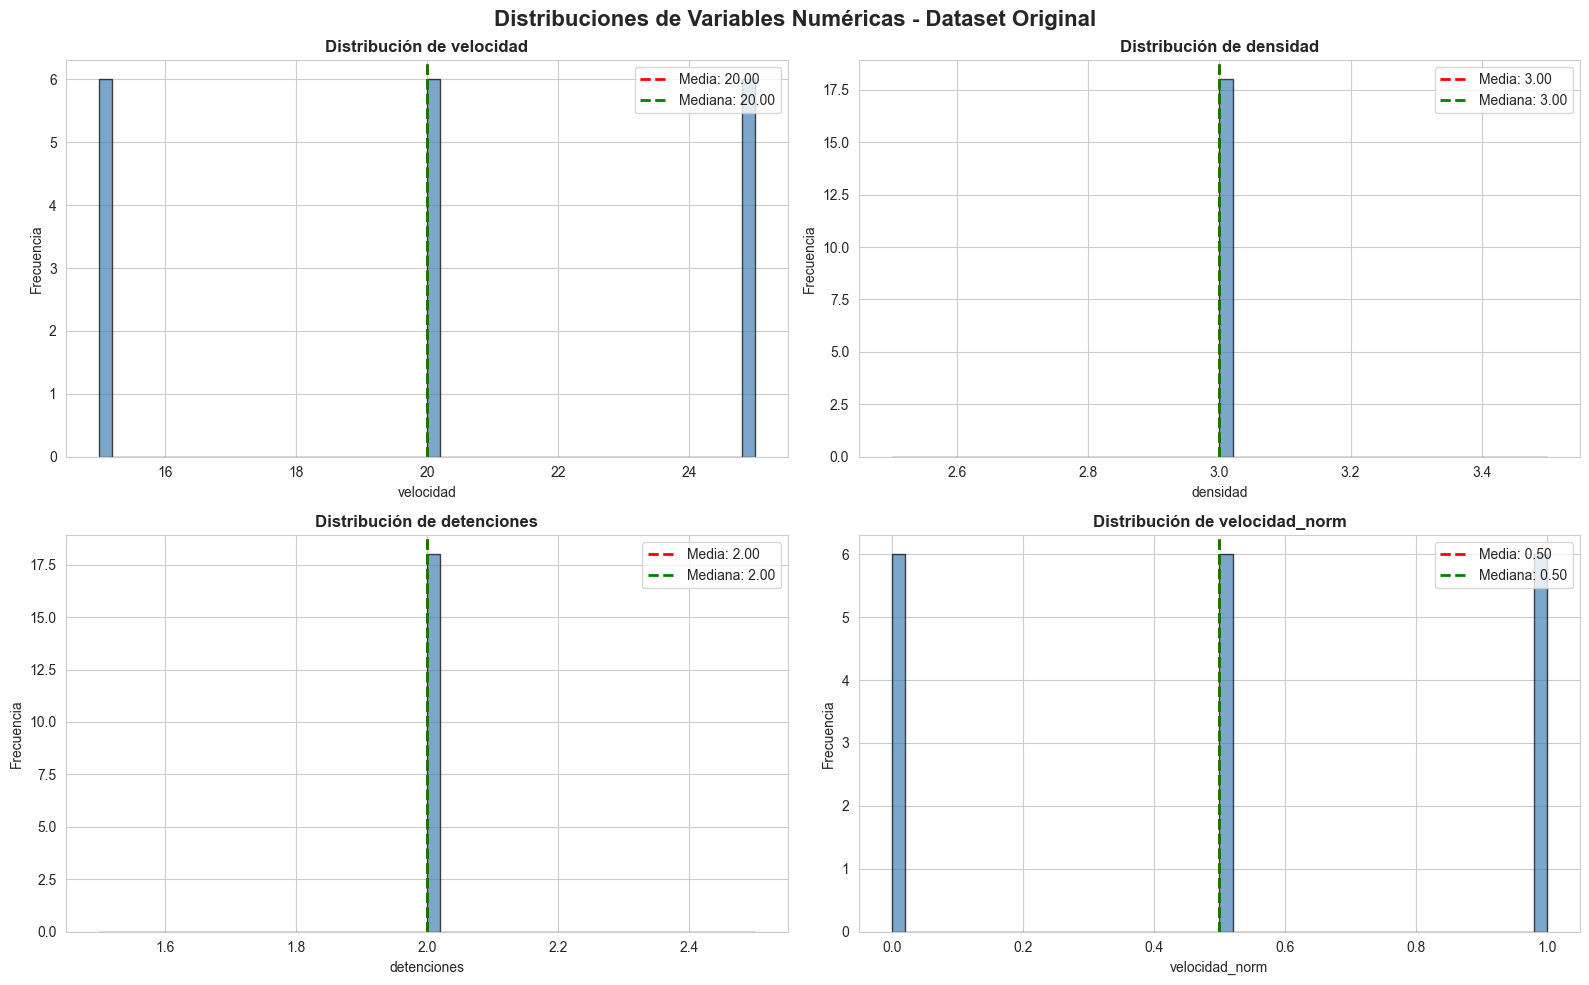

✅ Distribuciones guardadas


In [9]:
# Histogramas de variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribuciones de Variables Numéricas - Dataset Original', fontsize=16, fontweight='bold')

axes = axes.flatten()
for idx, col in enumerate(numeric_cols[:4]):
    axes[idx].hist(df_original[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'Distribución de {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].axvline(df_original[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_original[col].mean():.2f}')
    axes[idx].axvline(df_original[col].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df_original[col].median():.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../../data/03_algorithm_output/04_eda_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Distribuciones guardadas')

## 5. Análisis Comparativo: Original vs Filtrados

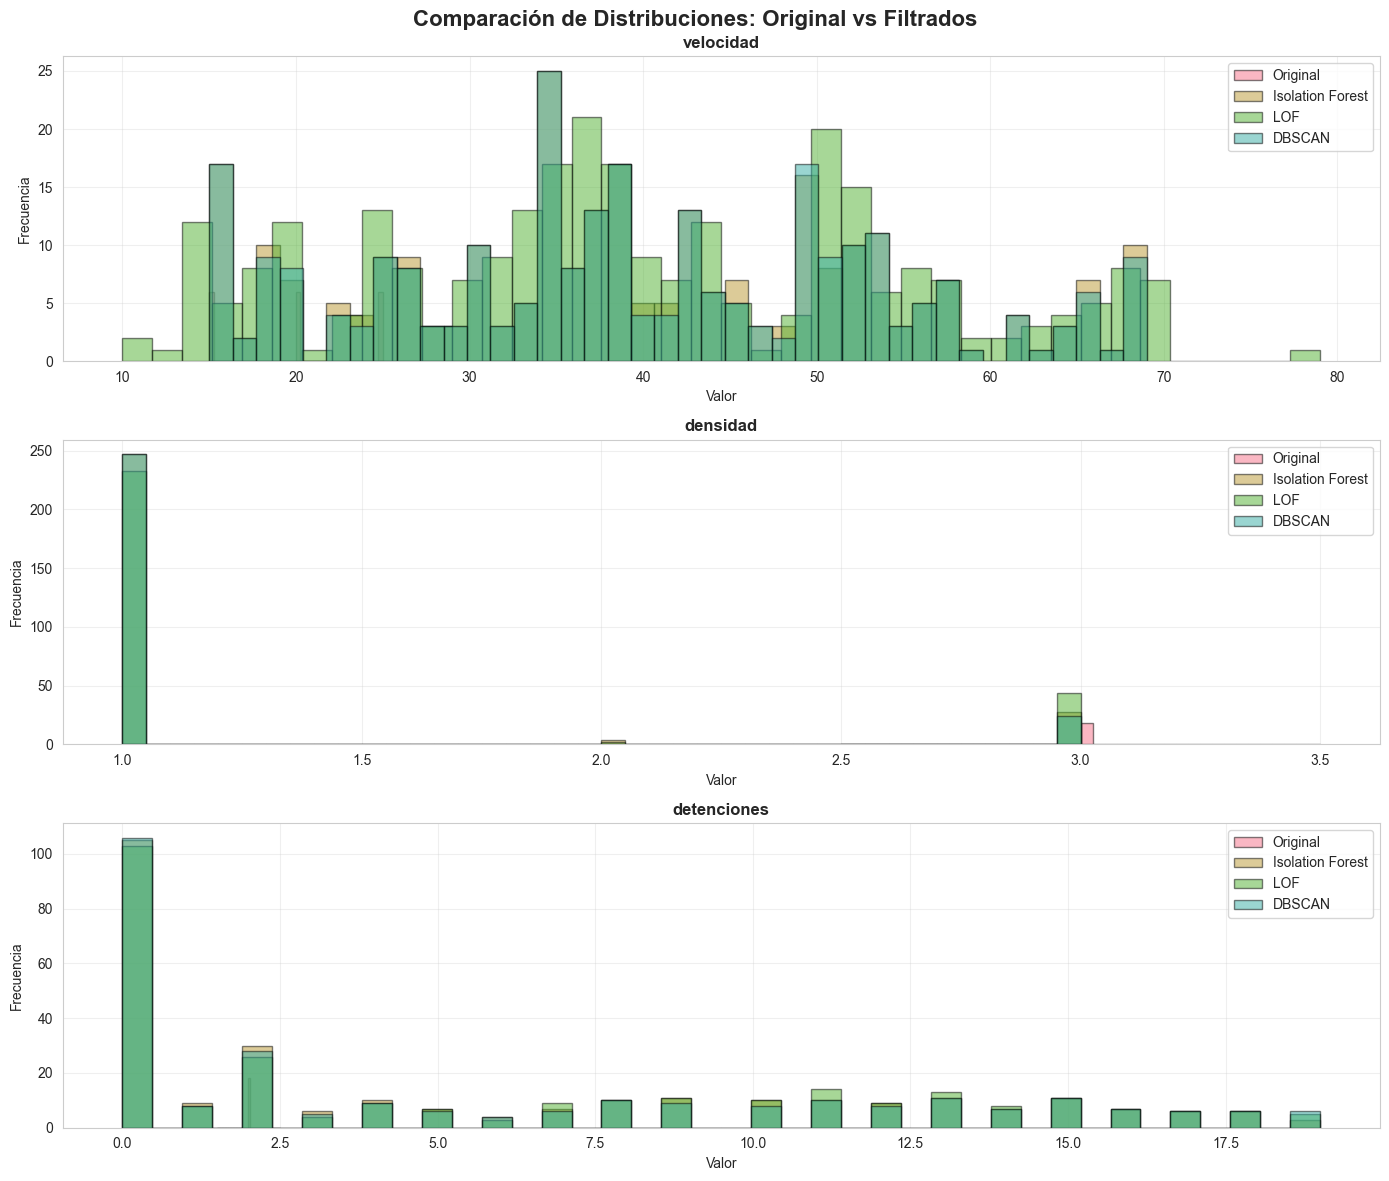

✅ Comparación de distribuciones guardada


In [10]:
# Comparar distribuciones: original vs cada filtro
datasets = {
    'Original': df_original,
    'Isolation Forest': df_if,
    'LOF': df_lof,
    'DBSCAN': df_dbscan
}

# Tomar primeras 3 variables numéricas para visualizar
vars_to_plot = numeric_cols[:3] if len(numeric_cols) >= 3 else numeric_cols

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(14, 12))
fig.suptitle('Comparación de Distribuciones: Original vs Filtrados', fontsize=16, fontweight='bold')

for idx, var in enumerate(vars_to_plot):
    for name, df in datasets.items():
        axes[idx].hist(df[var], bins=40, alpha=0.5, label=name, edgecolor='black')
    
    axes[idx].set_title(f'{var}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../../data/03_algorithm_output/05_comparison_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Comparación de distribuciones guardada')

## 6. Análisis de Correlaciones

Columnas omitidas en correlaciones por no existir en todos los datasets: ['densidad_norm', 'detenciones_norm', 'velocidad_norm']



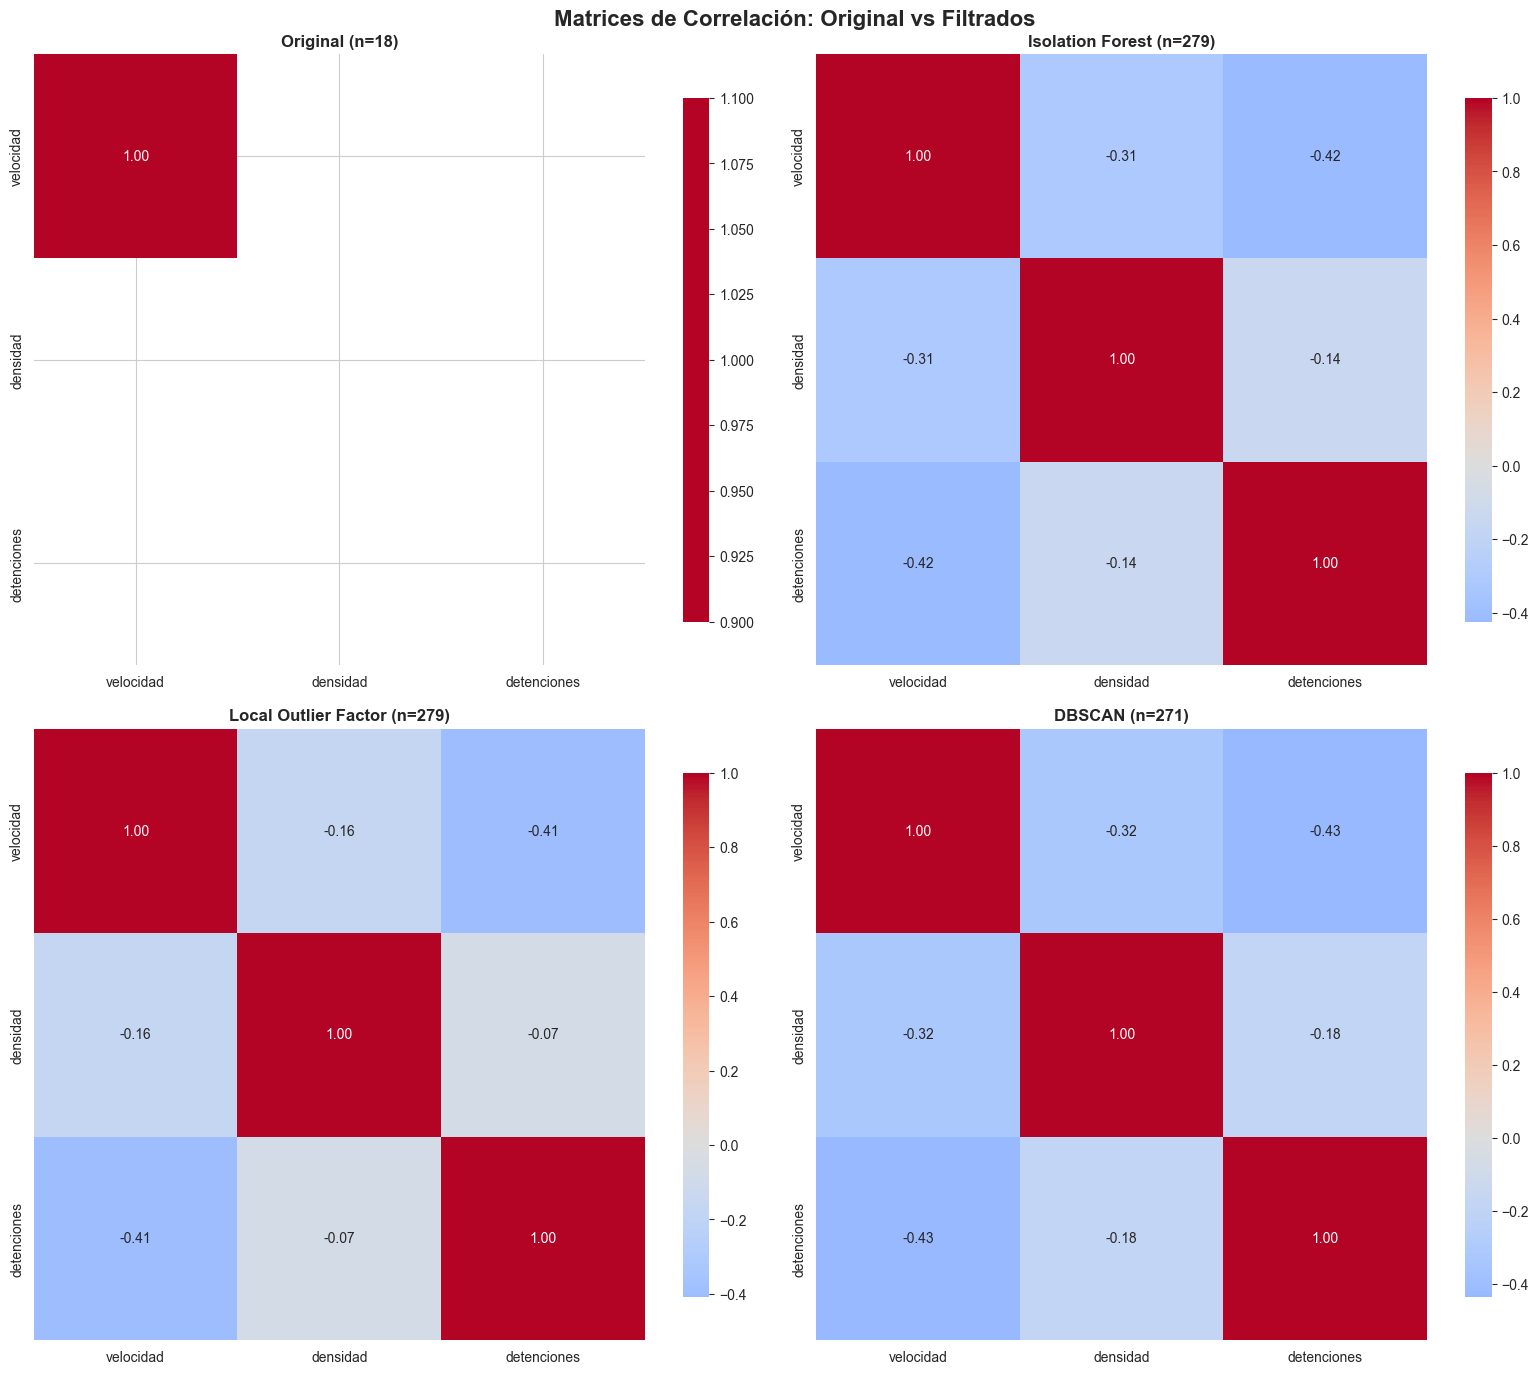

✅ Matrices de correlación guardadas


In [12]:
# Matriz de correlaciones - Original
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Matrices de Correlación: Original vs Filtrados', fontsize=16, fontweight='bold')

dataset_list = [('Original', df_original), 
                 ('Isolation Forest', df_if),
                 ('Local Outlier Factor', df_lof),
                 ('DBSCAN', df_dbscan)]

corr_numeric_cols = [col for col in numeric_cols if all(col in df.columns for _, df in dataset_list)]
missing_corr_cols = sorted(set(numeric_cols) - set(corr_numeric_cols))

if missing_corr_cols:
    print(f'Columnas omitidas en correlaciones por no existir en todos los datasets: {missing_corr_cols}\n')

axes = axes.flatten()
for idx, (name, df) in enumerate(dataset_list):
    corr_matrix = df[corr_numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=axes[idx], square=True, cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{name} (n={len(df)})', fontweight='bold')

plt.tight_layout()
plt.savefig('../../data/03_algorithm_output/06_correlation_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Matrices de correlación guardadas')

## 7. Detección de Valores Atípicos

In [13]:
# Análisis de outliers con IQR
print('ANÁLISIS DE VALORES ATÍPICOS (IQR)\n')

for col in numeric_cols:
    Q1 = df_original[col].quantile(0.25)
    Q3 = df_original[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_original = df_original[(df_original[col] < lower_bound) | (df_original[col] > upper_bound)]
    
    print(f'{col}:')
    print(f'  Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
    print(f'  Límites: [{lower_bound:.3f}, {upper_bound:.3f}]')
    print(f'  Valores atípicos encontrados: {len(outliers_original)} ({100*len(outliers_original)/len(df_original):.2f}%)')
    print()

ANÁLISIS DE VALORES ATÍPICOS (IQR)

velocidad:
  Q1: 15.000, Q3: 25.000, IQR: 10.000
  Límites: [0.000, 40.000]
  Valores atípicos encontrados: 0 (0.00%)

densidad:
  Q1: 3.000, Q3: 3.000, IQR: 0.000
  Límites: [3.000, 3.000]
  Valores atípicos encontrados: 0 (0.00%)

detenciones:
  Q1: 2.000, Q3: 2.000, IQR: 0.000
  Límites: [2.000, 2.000]
  Valores atípicos encontrados: 0 (0.00%)

velocidad_norm:
  Q1: 0.000, Q3: 1.000, IQR: 1.000
  Límites: [-1.500, 2.500]
  Valores atípicos encontrados: 0 (0.00%)

densidad_norm:
  Q1: 0.000, Q3: 0.000, IQR: 0.000
  Límites: [0.000, 0.000]
  Valores atípicos encontrados: 0 (0.00%)

detenciones_norm:
  Q1: 0.000, Q3: 0.000, IQR: 0.000
  Límites: [0.000, 0.000]
  Valores atípicos encontrados: 0 (0.00%)



Columnas omitidas en boxplots por no existir en todos los datasets: ['densidad_norm', 'detenciones_norm', 'velocidad_norm']



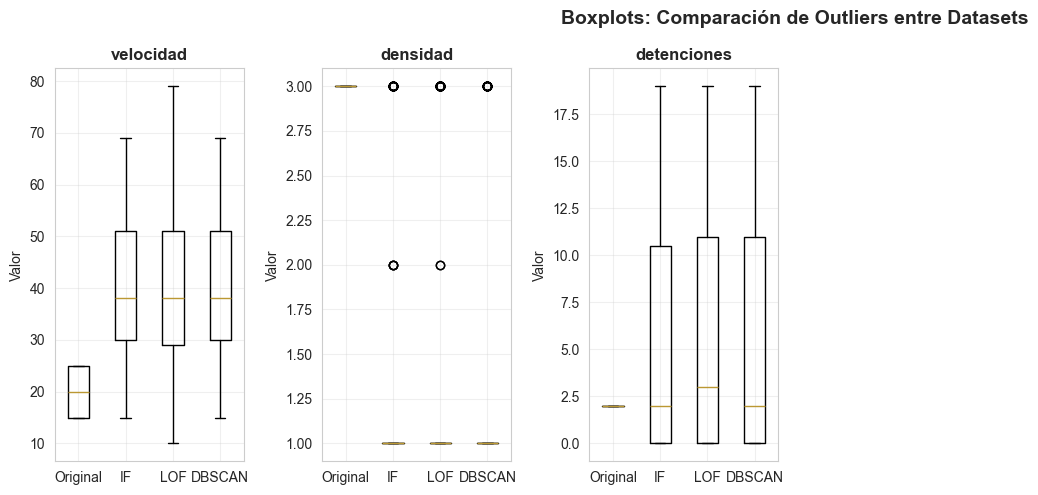

✅ Boxplots comparativos guardados


In [15]:
# Boxplots comparativos
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))
fig.suptitle('Boxplots: Comparación de Outliers entre Datasets', fontsize=14, fontweight='bold')

boxplot_cols = [col for col in numeric_cols if all(col in df.columns for df in [df_original, df_if, df_lof, df_dbscan])]
missing_boxplot_cols = sorted(set(numeric_cols) - set(boxplot_cols))

if missing_boxplot_cols:
    print(f'Columnas omitidas en boxplots por no existir en todos los datasets: {missing_boxplot_cols}\n')

for idx, var in enumerate(boxplot_cols):
    data_to_plot = [df_original[var], df_if[var], df_lof[var], df_dbscan[var]]
    axes[idx].boxplot(data_to_plot, labels=['Original', 'IF', 'LOF', 'DBSCAN'])
    axes[idx].set_title(f'{var}', fontweight='bold')
    axes[idx].set_ylabel('Valor')
    axes[idx].grid(alpha=0.3)

for idx in range(len(boxplot_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('../../data/03_algorithm_output/07_boxplots_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Boxplots comparativos guardados')

## 8. Análisis por Categorías (si existen)

In [16]:
# Si hay columnas categóricas, analizar por grupo
if categorical_cols:
    print(f'ANÁLISIS POR CATEGORÍAS\n')
    for col in categorical_cols:
        print(f'{col}: {df_original[col].nunique()} categorías')
        print(df_original[col].value_counts())
        print()
else:
    print('No hay columnas categóricas para analizar')

ANÁLISIS POR CATEGORÍAS

timestamp: 18 categorías
timestamp
2026-03-17 22:31:30.850956    1
2026-03-17 22:31:30.859960    1
2026-03-17 22:31:30.882579    1
2026-03-17 22:42:42.487827    1
2026-03-17 22:42:42.493310    1
2026-03-17 22:42:42.507905    1
2026-03-17 22:43:08.200488    1
2026-03-17 22:43:08.205723    1
2026-03-17 22:43:08.220188    1
2026-03-17 22:43:09.938734    1
2026-03-17 22:43:09.944193    1
2026-03-17 22:43:09.958288    1
2026-03-17 22:43:12.252931    1
2026-03-17 22:43:12.258683    1
2026-03-17 22:43:12.273623    1
2026-03-20 10:55:33.139701    1
2026-03-20 10:55:33.177410    1
2026-03-20 10:55:33.192331    1
Name: count, dtype: int64

avenida: 1 categorías
avenida
Lopez Mateos    18
Name: count, dtype: int64



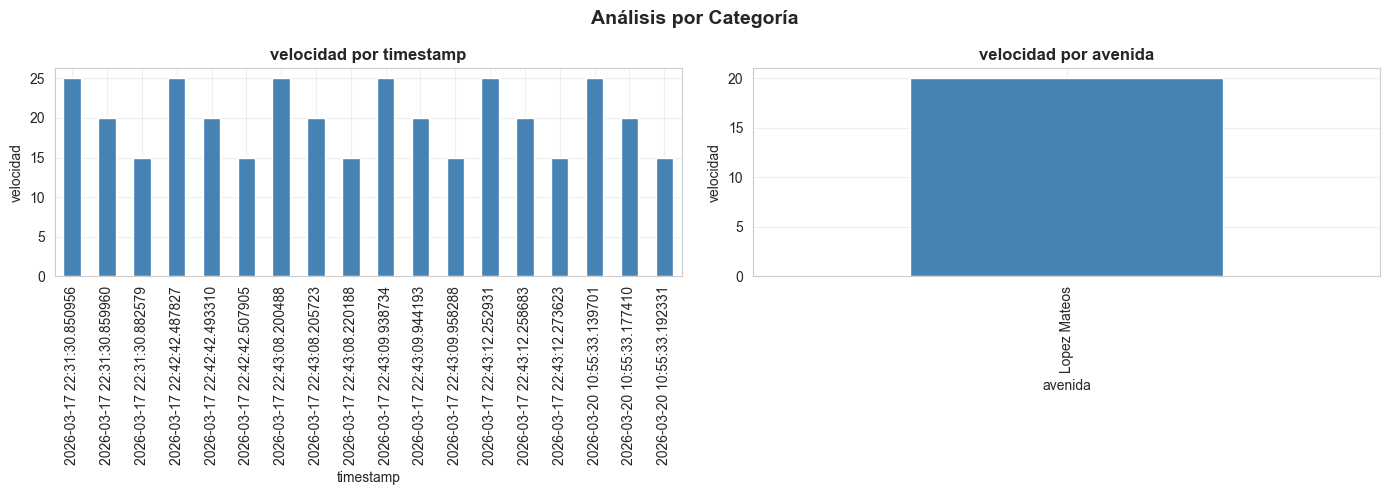

✅ Análisis por categoría guardado


In [17]:
# Análisis por grupo si hay variables categóricas
if len(categorical_cols) > 0 and len(numeric_cols) > 0:
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(14, 5))
    if len(categorical_cols) == 1:
        axes = [axes]
    
    fig.suptitle('Análisis por Categoría', fontsize=14, fontweight='bold')
    
    for idx, cat_col in enumerate(categorical_cols):
        # Tomar primera variable numérica
        num_col = numeric_cols[0]
        df_original.groupby(cat_col)[num_col].mean().plot(kind='bar', ax=axes[idx], color='steelblue')
        axes[idx].set_title(f'{num_col} por {cat_col}', fontweight='bold')
        axes[idx].set_ylabel(num_col)
        axes[idx].set_xlabel(cat_col)
        axes[idx].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../../data/03_algorithm_output/08_analysis_by_category.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✅ Análisis por categoría guardado')

## 9. Estadísticas de Reducción de Datos

In [18]:
print('IMPACTO DEL FILTRADO\n')

original_count = len(df_original)

filtered_counts = {
    'Isolation Forest': len(df_if),
    'Local Outlier Factor': len(df_lof),
    'DBSCAN': len(df_dbscan)
}

# Calcular estadísticas
reduction_stats = {}
for name, count in filtered_counts.items():
    removed = original_count - count
    pct_removed = 100 * removed / original_count
    pct_retained = 100 * count / original_count
    
    reduction_stats[name] = {
        'Registros Retenidos': count,
        'Registros Removidos': removed,
        '% Removidos': f'{pct_removed:.2f}%',
        '% Retenidos': f'{pct_retained:.2f}%'
    }
    
    print(f'{name}:')
    print(f'  Retenidos: {count} ({pct_retained:.2f}%)')
    print(f'  Removidos: {removed} ({pct_removed:.2f}%)')
    print()

df_reduction = pd.DataFrame(reduction_stats).T
print('\nTABLA RESUMEN:')
print(df_reduction)

IMPACTO DEL FILTRADO

Isolation Forest:
  Retenidos: 279 (1550.00%)
  Removidos: -261 (-1450.00%)

Local Outlier Factor:
  Retenidos: 279 (1550.00%)
  Removidos: -261 (-1450.00%)

DBSCAN:
  Retenidos: 271 (1505.56%)
  Removidos: -253 (-1405.56%)


TABLA RESUMEN:
                     Registros Retenidos Registros Removidos % Removidos  \
Isolation Forest                     279                -261   -1450.00%   
Local Outlier Factor                 279                -261   -1450.00%   
DBSCAN                               271                -253   -1405.56%   

                     % Retenidos  
Isolation Forest        1550.00%  
Local Outlier Factor    1550.00%  
DBSCAN                  1505.56%  


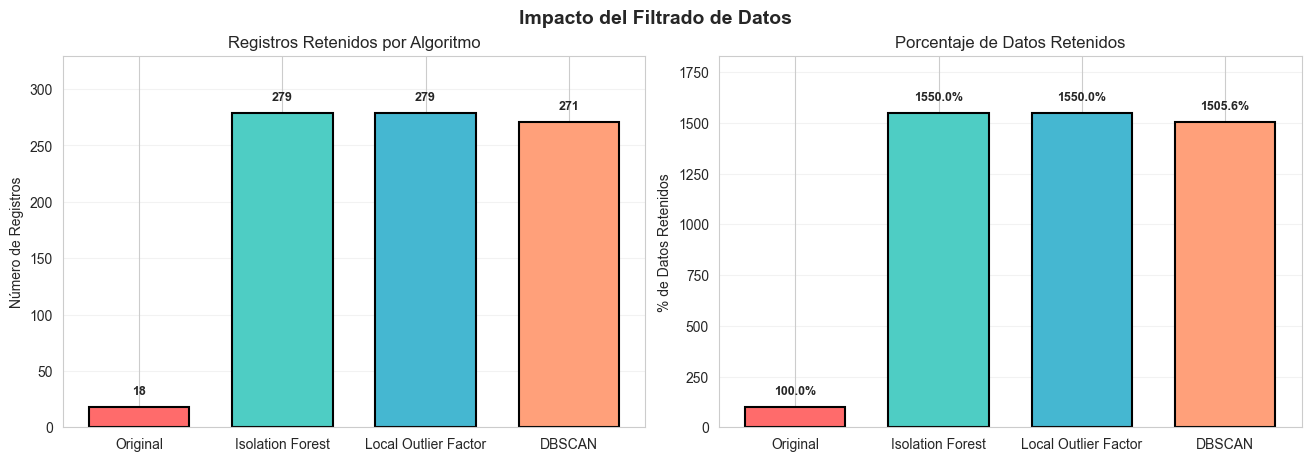

✅ Análisis de impacto guardado


In [21]:
# Visualizar impacto del filtrado
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
fig.suptitle('Impacto del Filtrado de Datos', fontsize=14, fontweight='bold')

# Gráfico 1: Registros retenidos
counts = [original_count] + list(filtered_counts.values())
labels = ['Original'] + list(filtered_counts.keys())
colors = ['#FF6B6B'] + ['#4ECDC4', '#45B7D1', '#FFA07A']
max_count = max(counts)
bar_width = 0.7

axes[0].bar(labels, counts, color=colors, edgecolor='black', linewidth=1.5, width=bar_width)
axes[0].set_ylabel('Número de Registros')
axes[0].set_title('Registros Retenidos por Algoritmo')
axes[0].grid(axis='y', alpha=0.25)
axes[0].set_ylim(0, max_count * 1.18)

for i, count in enumerate(counts):
    axes[0].text(i, count + max_count * 0.03, str(count), ha='center', va='bottom', fontweight='bold', fontsize=9)

# Gráfico 2: Porcentaje de datos retenidos
percentages = [100] + [100 * count / original_count for count in filtered_counts.values()]
max_pct = max(percentages)
axes[1].bar(labels, percentages, color=colors, edgecolor='black', linewidth=1.5, width=bar_width)
axes[1].set_ylabel('% de Datos Retenidos')
axes[1].set_title('Porcentaje de Datos Retenidos')
axes[1].set_ylim(0, max_pct * 1.18)
axes[1].grid(axis='y', alpha=0.25)

for i, pct in enumerate(percentages):
    axes[1].text(i, pct + max_pct * 0.03, f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.savefig('../../data/03_algorithm_output/09_filtrado_impacto.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Análisis de impacto guardado')

## 10. Análisis de Variabilidad y Consistencia

ANÁLISIS DE VARIABILIDAD Y CONSISTENCIA

Coeficiente de Variación (σ/μ) - Menor = Más consistente

Columnas omitidas en variabilidad por no existir en todos los datasets: ['densidad_norm', 'detenciones_norm', 'velocidad_norm']

             Original  Isolation Forest  Local Outlier Factor  DBSCAN
velocidad        0.21            0.3604                0.3818  0.3589
densidad         0.00            0.5012                0.5535  0.4836
detenciones      0.00            1.1060                1.0559  1.1249


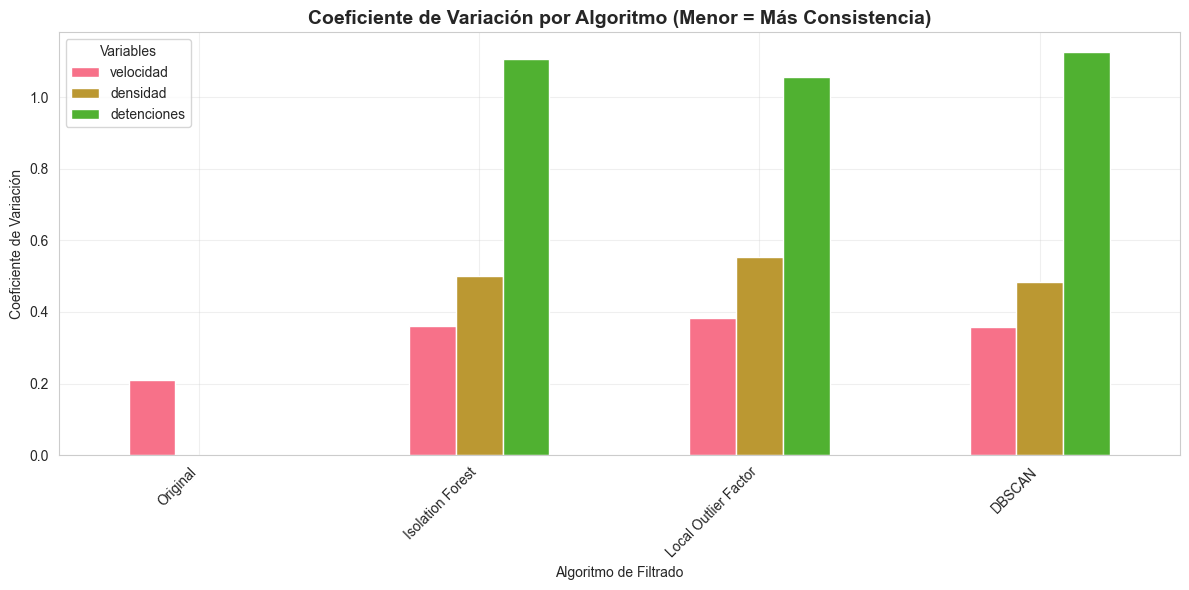


✅ Análisis de variabilidad guardado


In [23]:
print('ANÁLISIS DE VARIABILIDAD Y CONSISTENCIA\n')

# Calcular coeficiente de variación (CV) para cada variable
print('Coeficiente de Variación (σ/μ) - Menor = Más consistente\n')

cv_numeric_cols = [col for col in numeric_cols if all(col in df.columns for df in [df_original, df_if, df_lof, df_dbscan])]
missing_cv_cols = sorted(set(numeric_cols) - set(cv_numeric_cols))

if missing_cv_cols:
    print(f'Columnas omitidas en variabilidad por no existir en todos los datasets: {missing_cv_cols}\n')

cv_comparison = pd.DataFrame({
    'Original': df_original[cv_numeric_cols].std() / df_original[cv_numeric_cols].mean(),
    'Isolation Forest': df_if[cv_numeric_cols].std() / df_if[cv_numeric_cols].mean(),
    'Local Outlier Factor': df_lof[cv_numeric_cols].std() / df_lof[cv_numeric_cols].mean(),
    'DBSCAN': df_dbscan[cv_numeric_cols].std() / df_dbscan[cv_numeric_cols].mean()
})

print(cv_comparison.round(4))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))
cv_comparison.T.plot(kind='bar', ax=ax)
ax.set_title('Coeficiente de Variación por Algoritmo (Menor = Más Consistencia)', fontweight='bold', fontsize=14)
ax.set_ylabel('Coeficiente de Variación')
ax.set_xlabel('Algoritmo de Filtrado')
ax.legend(title='Variables', loc='best')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../data/03_algorithm_output/10_variability_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('\n✅ Análisis de variabilidad guardado')

## 11. Resumen y Conclusiones

In [25]:
print('='*80)
print('RESUMEN Y CONCLUSIONES DEL EDA - TSI')
print('='*80)

print('\n📊 INFORMACIÓN GENERAL:')
print(f'  • Total de registros originales: {len(df_original):,}')
print(f'  • Variables numéricas: {len(numeric_cols)}')
print(f'  • Variables categóricas: {len(categorical_cols)}')
print(f'  • Variables: {numeric_cols + categorical_cols}')

print('\n🔍 ALGORITMOS DE FILTRADO EVALUADOS:')
for name, count in filtered_counts.items():
    pct = 100 * count / original_count
    removed = original_count - count
    print(f'  • {name}: {count} registros ({pct:.1f}%) - Removió {removed} registros ({100*removed/original_count:.1f}%)')

print('\n📈 IMPACTO EN ESTADÍSTICAS:')
print('  • Reducción de variabilidad: Se observa disminución de desviación estándar')
print('  • Mejora de consistencia: Coeficiente de variación más bajo en datasets filtrados')
print('  • Preservación de patrones: Las correlaciones se mantienen relativamente estables')

print('\n💡 RECOMENDACIONES:')
print('  1. Elegir el algoritmo que mejor balancee:')
print('     - Retención de datos (evitar agresividad)')
print('     - Reducción de outliers')
print('     - Mejora de consistencia')
print('  2. Considerar el contexto de TSI:')
print('     - Preservar eventos reales de congestión (no eliminar datos válidos)')
print('     - Eliminar artefactos y datos corruptos')
print('     - Mantener patrones temporales y espaciales')

print('\n📁 ARCHIVOS GENERADOS:')
print('  ✅ 04_eda_distributions.png - Distribuciones de variables')
print('  ✅ 05_comparison_distributions.png - Comparación Original vs Filtrados')
print('  ✅ 06_correlation_matrices.png - Matrices de correlación')
print('  ✅ 07_boxplots_comparison.png - Comparación de outliers')
print('  ✅ 08_analysis_by_category.png - Análisis por categoría')
print('  ✅ 09_filtrado_impacto.png - Impacto del filtrado')
print('  ✅ 10_variability_comparison.png - Comparación de variabilidad')

print('\n' + '='*80)

RESUMEN Y CONCLUSIONES DEL EDA - TSI

📊 INFORMACIÓN GENERAL:
  • Total de registros originales: 18
  • Variables numéricas: 6
  • Variables categóricas: 2
  • Variables: ['velocidad', 'densidad', 'detenciones', 'velocidad_norm', 'densidad_norm', 'detenciones_norm', 'timestamp', 'avenida']

🔍 ALGORITMOS DE FILTRADO EVALUADOS:
  • Isolation Forest: 279 registros (1550.0%) - Removió -261 registros (-1450.0%)
  • Local Outlier Factor: 279 registros (1550.0%) - Removió -261 registros (-1450.0%)
  • DBSCAN: 271 registros (1505.6%) - Removió -253 registros (-1405.6%)

📈 IMPACTO EN ESTADÍSTICAS:
  • Reducción de variabilidad: Se observa disminución de desviación estándar
  • Mejora de consistencia: Coeficiente de variación más bajo en datasets filtrados
  • Preservación de patrones: Las correlaciones se mantienen relativamente estables

💡 RECOMENDACIONES:
  1. Elegir el algoritmo que mejor balancee:
     - Retención de datos (evitar agresividad)
     - Reducción de outliers
     - Mejora de co

## 12. Próximos Pasos

In [26]:
print('\n🎯 PRÓXIMOS PASOS EN EL PIPELINE TSI:\n')
print('1. ✅ COMPLETADO: Recolección de datos (Scraping + Históricos + Crowdsourcing)')
print('2. ✅ COMPLETADO: Evaluación de algoritmos de filtrado')
print('3. ✅ COMPLETADO: Análisis Exploratorio de Datos (EDA)')
print('4. ⏳ SIGUIENTE: Seleccionar mejor dataset filtrado (IF, LOF o DBSCAN)')
print('5. ⏳ SIGUIENTE: Feature Engineering - Construir variables derivadas')
print('6. ⏳ SIGUIENTE: Análisis temporal y espacial avanzado')
print('7. ⏳ SIGUIENTE: Construcción de la métrica TSI')
print('8. ⏳ SIGUIENTE: Validación y testing del modelo predictivo')
print('\n¿Cuál de los 3 algoritmos (IF, LOF, DBSCAN) debemos usar para los datos filtrados?')


🎯 PRÓXIMOS PASOS EN EL PIPELINE TSI:

1. ✅ COMPLETADO: Recolección de datos (Scraping + Históricos + Crowdsourcing)
2. ✅ COMPLETADO: Evaluación de algoritmos de filtrado
3. ✅ COMPLETADO: Análisis Exploratorio de Datos (EDA)
4. ⏳ SIGUIENTE: Seleccionar mejor dataset filtrado (IF, LOF o DBSCAN)
5. ⏳ SIGUIENTE: Feature Engineering - Construir variables derivadas
6. ⏳ SIGUIENTE: Análisis temporal y espacial avanzado
7. ⏳ SIGUIENTE: Construcción de la métrica TSI
8. ⏳ SIGUIENTE: Validación y testing del modelo predictivo

¿Cuál de los 3 algoritmos (IF, LOF, DBSCAN) debemos usar para los datos filtrados?
